# CaSR-Driven Results in March, Jun, September and December(hopefully)



## Lead Data

In [ ]:
# CaSR Paths

path_CaSR_mar_biol='/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_biol_T.nc'
path_CaSR_jun_biol='/ocean/jqiu/results/Flux/flux_00jun23_CaSR/SalishSea_1d_20230601_20230630_biol_T.nc'
path_CaSR_sep_biol='/ocean/jqiu/results/Flux/flux_00sep23_CaSR/SalishSea_1d_20230901_20230930_biol_T.nc'
path_CaSR_dec_biol='' # Dec not available yet

path_CaSR_mar_t='/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_grid_T.nc'
path_CaSR_jun_t='/ocean/jqiu/results/Flux/flux_00jun23_CaSR/SalishSea_1d_20230601_20230630_grid_T.nc'
path_CaSR_sep_t='/ocean/jqiu/results/Flux/flux_00sep23_CaSR/SalishSea_1d_20230901_20230930_grid_T.nc'
path_CaSR_dec_t='' # Dec not available yet

# HRDPS Paths
# Example path: '/results2/SalishSea/nowcast-green.202111/01mar23/SalishSea_1d_20230301_20230301_grid_T.nc'

## Sea Temperature

### SST Difference Map

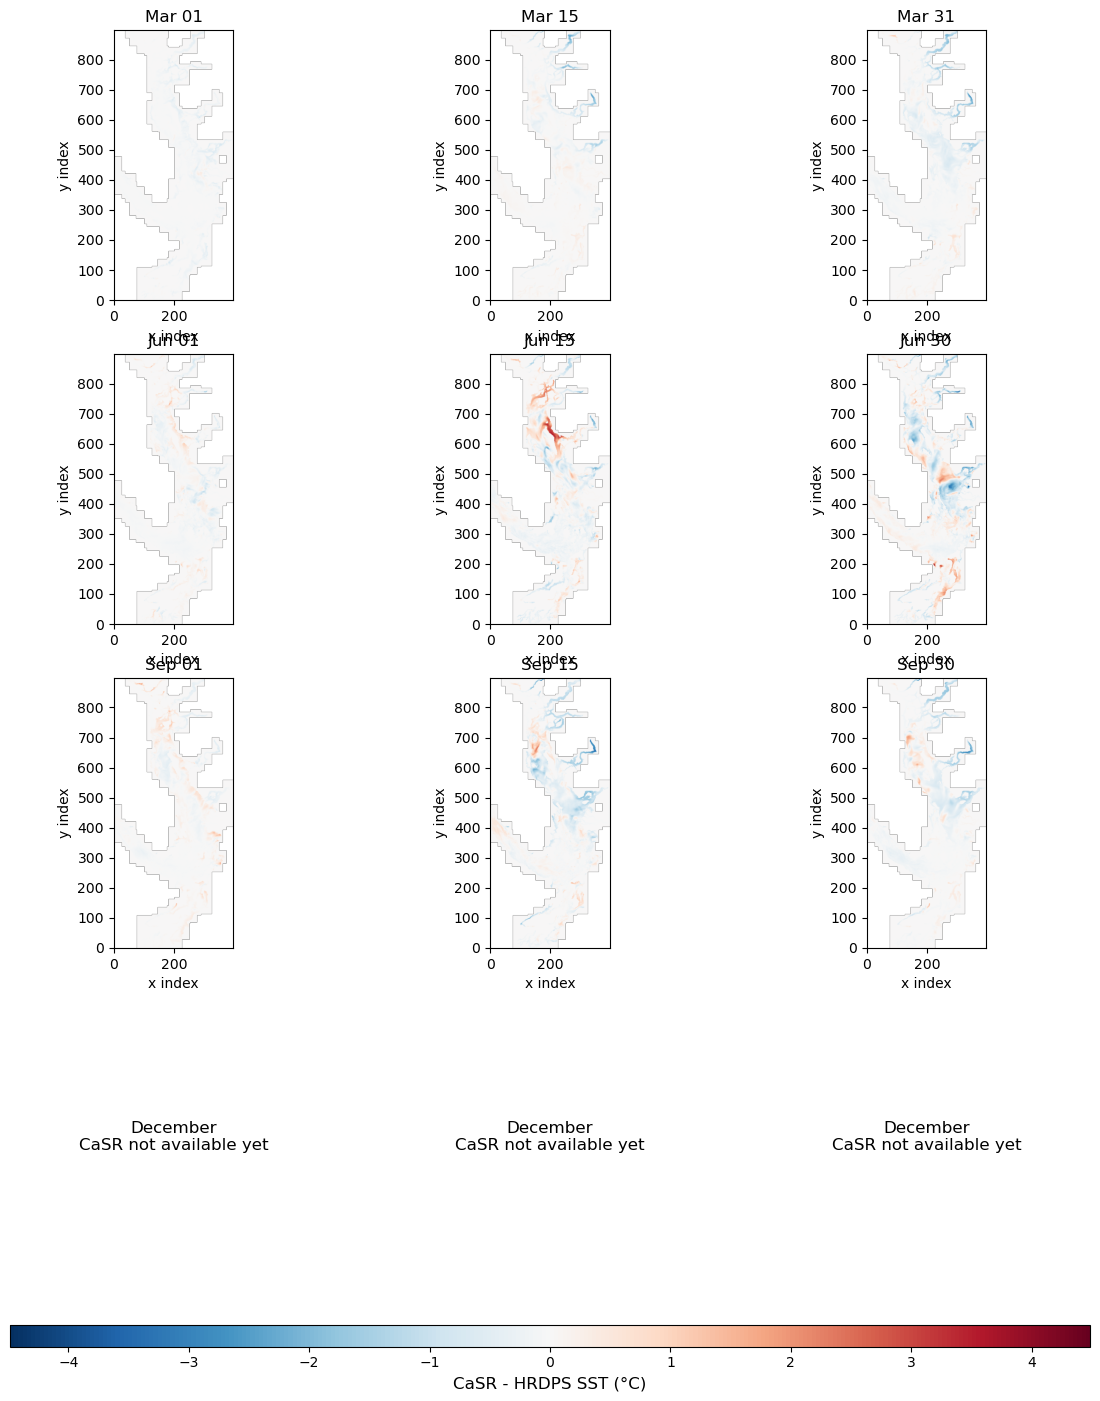

In [5]:
# SST diff in Mar, Jun, Sep and Dec

import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# CaSR monthly grid_T paths
# ============================================================
path_CaSR_mar_t = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_CaSR_jun_t = (
    '/ocean/jqiu/results/Flux/flux_00jun23_CaSR/'
    'SalishSea_1d_20230601_20230630_grid_T.nc'
)

path_CaSR_sep_t = (
    '/ocean/jqiu/results/Flux/flux_00sep23_CaSR/'
    'SalishSea_1d_20230901_20230930_grid_T.nc'
)

# December CaSR is not available yet
# path_CaSR_dec_t = (
#     '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
#     'SalishSea_1d_20231201_20231231_grid_T.nc'
# )


# ============================================================
# HRDPS server base path
#
# Example:
# /results2/SalishSea/nowcast-green.202111/
# 01mar23/
# SalishSea_1d_20230301_20230301_grid_T.nc
# ============================================================
path_HRDPS_base = (
    '/results2/SalishSea/nowcast-green.202111'
)


# ============================================================
# Month configuration
#
# Each row = one month
# Each column = one selected day
# ============================================================
months = [
    {
        'name': 'March',
        'short': 'Mar',
        'month_num': 3,
        'month_str': 'mar',
        'casr_path': path_CaSR_mar_t,
        'days': [1, 15, 31],
    },
    {
        'name': 'June',
        'short': 'Jun',
        'month_num': 6,
        'month_str': 'jun',
        'casr_path': path_CaSR_jun_t,
        'days': [1, 15, 30],
    },
    {
        'name': 'September',
        'short': 'Sep',
        'month_num': 9,
        'month_str': 'sep',
        'casr_path': path_CaSR_sep_t,
        'days': [1, 15, 30],
    },

    # ========================================================
    # December: uncomment after CaSR is ready
    # ========================================================
    # {
    #     'name': 'December',
    #     'short': 'Dec',
    #     'month_num': 12,
    #     'month_str': 'dec',
    #     'casr_path': path_CaSR_dec_t,
    #     'days': [1, 15, 31],
    # },
]


# ============================================================
# Surface layer
# ============================================================
depth_idx = 0


# ============================================================
# Function to build HRDPS daily file path
#
# Example for March 1:
#
# /results2/SalishSea/nowcast-green.202111/
# 01mar23/
# SalishSea_1d_20230301_20230301_grid_T.nc
# ============================================================
def get_hrdps_path(month_num, month_str, day_num):

    date_str = f'2023{month_num:02d}{day_num:02d}'

    folder = f'{day_num:02d}{month_str}23'

    filename = (
        f'SalishSea_1d_'
        f'{date_str}_{date_str}_grid_T.nc'
    )

    path = os.path.join(
        path_HRDPS_base,
        folder,
        filename
    )

    return path


# ============================================================
# Read SST differences
#
# positive = CaSR warmer than HRDPS
# negative = CaSR colder than HRDPS
# ============================================================
all_data = []


for month in months:


    # --------------------------------------------------------
    # CaSR is one monthly file
    # --------------------------------------------------------
    casr_ds = xr.open_dataset(
        month['casr_path']
    )

    month_data = []

    for day_num in month['days']:

        # ====================================================
        # CaSR monthly-file time index
        #
        # day 1  -> index 0
        # day 15 -> index 14
        # day 31 -> index 30
        # ====================================================
        tidx = day_num - 1

        # ====================================================
        # HRDPS daily file
        # ====================================================
        hrdps_path = get_hrdps_path(
            month_num=month['month_num'],
            month_str=month['month_str'],
            day_num=day_num
        )



        # Optional safety check
        if not os.path.exists(hrdps_path):
            raise FileNotFoundError(
                f'HRDPS file not found:\n{hrdps_path}'
            )

        hrdps_ds = xr.open_dataset(
            hrdps_path
        )


        # ====================================================
        # CaSR SST
        # ====================================================
        casr_sst = casr_ds['votemper'].isel(
            time_counter=tidx,
            deptht=depth_idx
        ).values


        # ====================================================
        # HRDPS SST
        #
        # Each HRDPS file contains only one day,
        # so time index = 0
        # ====================================================
        hrdps_sst = hrdps_ds['votemper'].isel(
            time_counter=0,
            deptht=depth_idx
        ).values


        # ====================================================
        # Difference
        #
        # positive = CaSR warmer
        # negative = CaSR colder
        # ====================================================
        diff = casr_sst - hrdps_sst


        # ====================================================
        # Time information
        # ====================================================
        casr_time = casr_ds.time_counter.isel(
            time_counter=tidx
        ).values

        hrdps_time = hrdps_ds.time_counter.isel(
            time_counter=0
        ).values



        # ====================================================
        # Save
        # ====================================================
        month_data.append({
            'month': month['name'],
            'short': month['short'],
            'day': day_num,
            'diff': diff,
        })


        # ====================================================
        # Close HRDPS daily file
        # ====================================================
        hrdps_ds.close()


    all_data.append(
        month_data
    )

    casr_ds.close()


# ============================================================
# Unified difference color range
# across ALL available months and days
#
# symmetric around zero
# ============================================================
all_diff_values = []

for month_data in all_data:

    for data in month_data:

        valid = data['diff'][
            np.isfinite(data['diff'])
        ]

        if valid.size > 0:
            all_diff_values.append(
                valid
            )


all_diff_values = np.concatenate(
    all_diff_values
)


# ============================================================
# Option 1:
# absolute maximum
# ============================================================
diff_max = np.nanmax(
    np.abs(all_diff_values)
)




diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)



# ============================================================
# Plot: 4 rows × 3 columns
#
# March
# June
# September
# December -- blank for now
# ============================================================
fig, axes = plt.subplots(
    4,
    3,
    figsize=(12, 16)
)


# ============================================================
# Plot March, June, September
# ============================================================
im = None

for row, month_data in enumerate(all_data):

    for col, data in enumerate(month_data):

        im = axes[row, col].imshow(
            data['diff'],
            origin='lower',
            cmap='RdBu_r',
            norm=diff_norm,
            aspect='equal'
        )

        axes[row, col].set_title(
            f"{data['short']} {data['day']:02d}",
            fontsize=12
        )

        axes[row, col].set_xlabel(
            'x index'
        )

        axes[row, col].set_ylabel(
            'y index'
        )


# ============================================================
# December row:
# currently no CaSR data
# ============================================================
for col in range(3):

    axes[3, col].axis('off')

    axes[3, col].text(
        0.5,
        0.5,
        'December\nCaSR not available yet',
        transform=axes[3, col].transAxes,
        ha='center',
        va='center',
        fontsize=12
    )





# ============================================================
# Layout
# ============================================================
plt.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.93,
    bottom=0.10,
    wspace=0.15,
    hspace=0.20
)


# ============================================================
# ONE shared colorbar
# ============================================================
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    fraction=0.025,
    pad=0.04,
    aspect=50
)

cbar.set_label(
    'CaSR - HRDPS SST (°C)',
    fontsize=12
)

cbar.ax.tick_params(
    labelsize=10
)


plt.show()



### Sea Temperature Profiles

Pam Rocks   : 27 valid levels
Sand Heads  : 12 valid levels
Pam Rocks   : 27 valid levels
Sand Heads  : 12 valid levels
Pam Rocks   : 27 valid levels
Sand Heads  : 12 valid levels


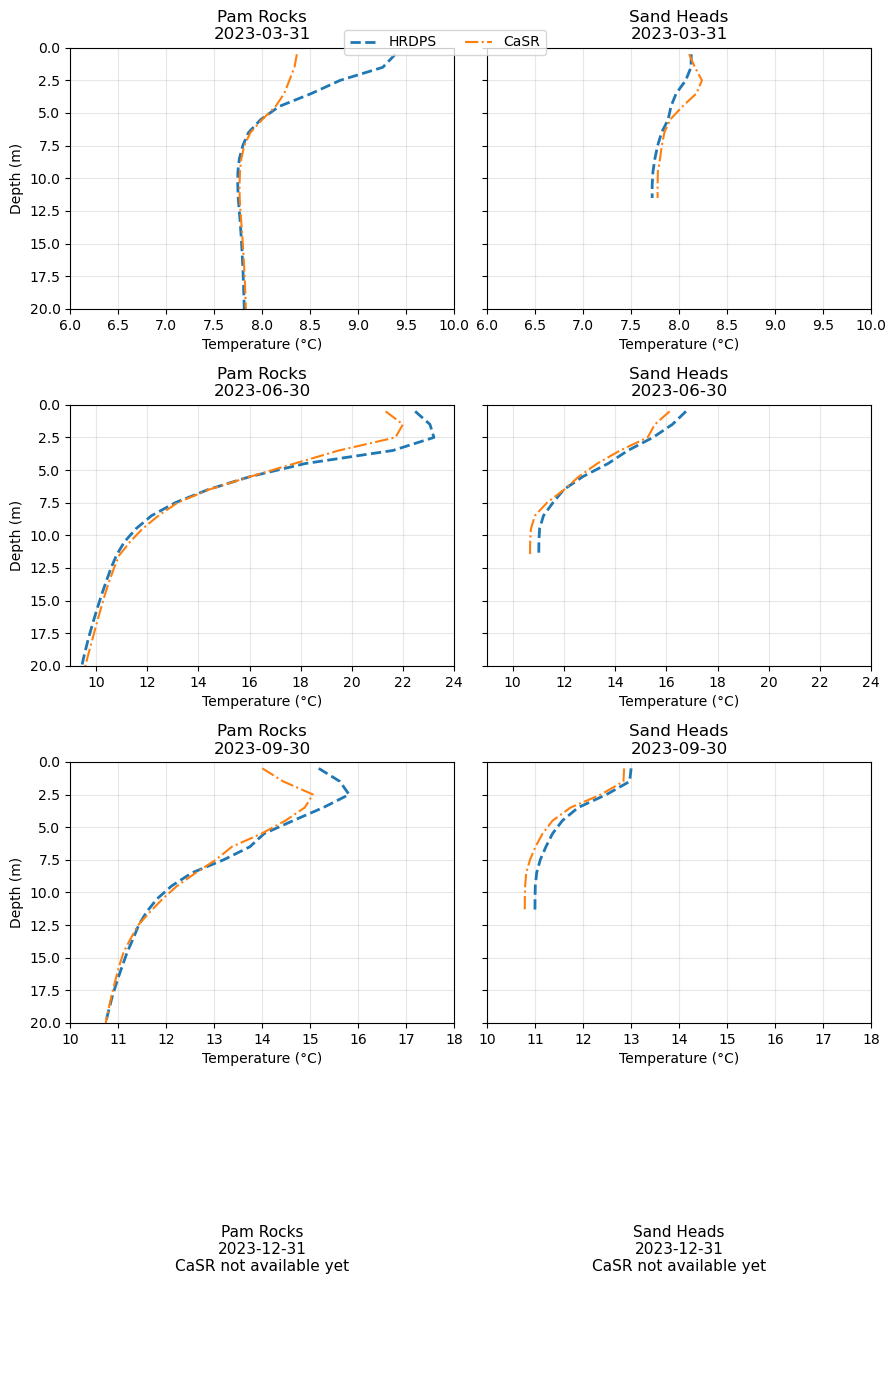

In [ ]:

import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CaSR monthly grid_T paths
# ============================================================
path_CaSR_mar_t = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_CaSR_jun_t = (
    '/ocean/jqiu/results/Flux/flux_00jun23_CaSR/'
    'SalishSea_1d_20230601_20230630_grid_T.nc'
)

path_CaSR_sep_t = (
    '/ocean/jqiu/results/Flux/flux_00sep23_CaSR/'
    'SalishSea_1d_20230901_20230930_grid_T.nc'
)

# December CaSR is not available yet
# path_CaSR_dec_t = (
#     '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
#     'SalishSea_1d_20231201_20231231_grid_T.nc'
# )


# ============================================================
# HRDPS server base path
# ============================================================
path_HRDPS_base = (
    '/results2/SalishSea/nowcast-green.202111'
)


# ============================================================
# Stations
# ============================================================
stations = [
    {
        'name': 'Pam Rocks',
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },
    {
        'name': 'Sand Heads',
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
]


# ============================================================
# Month information
#
# xlim is set manually for each month.
# Change these values yourself as needed.
# ============================================================
months = [
    {
        'name': 'March',
        'short': 'Mar',
        'month_num': 3,
        'month_str': 'mar',
        'last_day': 31,
        'casr_path': path_CaSR_mar_t,

        # --------------------------------------------
        # Manually set March temperature range
        # --------------------------------------------
        'xlim': (6, 10),
    },
    {
        'name': 'June',
        'short': 'Jun',
        'month_num': 6,
        'month_str': 'jun',
        'last_day': 30,
        'casr_path': path_CaSR_jun_t,

        # --------------------------------------------
        # Manually set June temperature range
        # --------------------------------------------
        'xlim': (9, 24),
    },
    {
        'name': 'September',
        'short': 'Sep',
        'month_num': 9,
        'month_str': 'sep',
        'last_day': 30,
        'casr_path': path_CaSR_sep_t,

        # --------------------------------------------
        # Manually set September temperature range
        # --------------------------------------------
        'xlim': (10, 18),
    },

    # ========================================================
    # December: uncomment when CaSR is ready
    # ========================================================
    # {
    #     'name': 'December',
    #     'short': 'Dec',
    #     'month_num': 12,
    #     'month_str': 'dec',
    #     'last_day': 31,
    #     'casr_path': path_CaSR_dec_t,
    #     'xlim': (6, 12),
    # },
]


# ============================================================
# Function to build HRDPS daily file path
# ============================================================
def get_hrdps_path(month_num, month_str, day_num):

    date_str = f'2023{month_num:02d}{day_num:02d}'

    folder = (
        f'{day_num:02d}'
        f'{month_str}'
        f'23'
    )

    filename = (
        f'SalishSea_1d_'
        f'{date_str}_{date_str}_grid_T.nc'
    )

    return os.path.join(
        path_HRDPS_base,
        folder,
        filename
    )


# ============================================================
# Read profiles
# ============================================================
profiles = []


for month in months:

    day = month['last_day']

    

    # ========================================================
    # Open CaSR monthly file
    # ========================================================
    casr_ds = xr.open_dataset(
        month['casr_path']
    )

    # ========================================================
    # CaSR monthly-file time index
    # ========================================================
    casr_tidx = day - 1


    # ========================================================
    # HRDPS daily file
    # ========================================================
    hrdps_path = get_hrdps_path(
        month_num=month['month_num'],
        month_str=month['month_str'],
        day_num=day
    )



    if not os.path.exists(hrdps_path):
        raise FileNotFoundError(
            f'HRDPS file not found:\n{hrdps_path}'
        )

    hrdps_ds = xr.open_dataset(
        hrdps_path
    )


    # ========================================================
    # Depth
    # ========================================================
    depth = casr_ds['deptht'].values


    # ========================================================
    # Time information
    # ========================================================
    casr_time = casr_ds.time_counter.isel(
        time_counter=casr_tidx
    ).values

    hrdps_time = hrdps_ds.time_counter.isel(
        time_counter=0
    ).values

  

    # ========================================================
    # Read profiles at both stations
    # ========================================================
    month_profiles = []

    for station in stations:

        # ----------------------------------------------------
        # CaSR
        # ----------------------------------------------------
        casr_profile = casr_ds['votemper'].isel(
            time_counter=casr_tidx,
            y=station['y'],
            x=station['x']
        ).values


        # ----------------------------------------------------
        # HRDPS
        # ----------------------------------------------------
        hrdps_profile = hrdps_ds['votemper'].isel(
            time_counter=0,
            y=station['y'],
            x=station['x']
        ).values


        # ====================================================
        # Mask bad values
        # ====================================================
        valid = (
            np.isfinite(depth)
            & np.isfinite(casr_profile)
            & np.isfinite(hrdps_profile)
            & (casr_profile != 0)
            & (hrdps_profile != 0)
        )


        month_profiles.append({
            'month': month['name'],
            'short': month['short'],
            'month_num': month['month_num'],
            'day': day,
            'station': station['name'],
            'depth': depth[valid],
            'hrdps': hrdps_profile[valid],
            'casr': casr_profile[valid],

            # Save manual x-axis range
            'xlim': month['xlim'],
        })


        


    profiles.append(
        month_profiles
    )


    # ========================================================
    # Close datasets
    # ========================================================
    casr_ds.close()
    hrdps_ds.close()


# ============================================================
# Plot
#
# 4 rows × 2 columns
#
# rows:
# March
# June
# September
# December
#
# columns:
# Pam Rocks
# Sand Heads
#
# IMPORTANT:
# sharex=False because each month has its own x range.
# ============================================================
fig, axes = plt.subplots(
    4,
    2,
    figsize=(9, 14),
    sharex=False,
    sharey=True
)


# ============================================================
# Plot available months
# ============================================================
for row, month_profiles in enumerate(profiles):

    for col, data in enumerate(month_profiles):

        ax = axes[row, col]

        profile_depth = data['depth']


        # ====================================================
        # HRDPS
        # ====================================================
        ax.plot(
            data['hrdps'],
            profile_depth,
            linewidth=2,
            linestyle='--',
            label='HRDPS'
        )


        # ====================================================
        # CaSR
        # ====================================================
        ax.plot(
            data['casr'],
            profile_depth,
            linewidth=1.5,
            linestyle='-.',
            label='CaSR'
        )


        # ====================================================
        # Manual x-axis range
        #
        # Same month -> same x range for both stations
        # ====================================================
        ax.set_xlim(
            data['xlim']
        )


        # ====================================================
        # Depth range
        # ====================================================
        ax.set_ylim(
            20,
            0
        )


        # ====================================================
        # Title
        # ====================================================
        ax.set_title(
            f"{data['station']}\n"
            f"2023-{data['month_num']:02d}-{data['day']:02d}"
        )


        # ====================================================
        # Every panel gets its own x-axis label and ticks
        # ====================================================
        ax.set_xlabel(
            'Temperature (°C)'
        )

        ax.tick_params(
            axis='x',
            labelbottom=True
        )


        # ====================================================
        # Y label
        # ====================================================
        if col == 0:
            ax.set_ylabel(
                'Depth (m)'
            )


        ax.grid(
            alpha=0.3
        )


# ============================================================
# December row
#
# CaSR not available yet
# ============================================================
for col, station in enumerate(stations):

    axes[3, col].axis('off')

    axes[3, col].text(
        0.5,
        0.5,
        f"{station['name']}\n"
        f"2023-12-31\n"
        f"CaSR not available yet",
        transform=axes[3, col].transAxes,
        ha='center',
        va='center',
        fontsize=11
    )


# ============================================================
# Shared legend
# ============================================================
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.98)
)





plt.tight_layout()

plt.show()



### Time Series

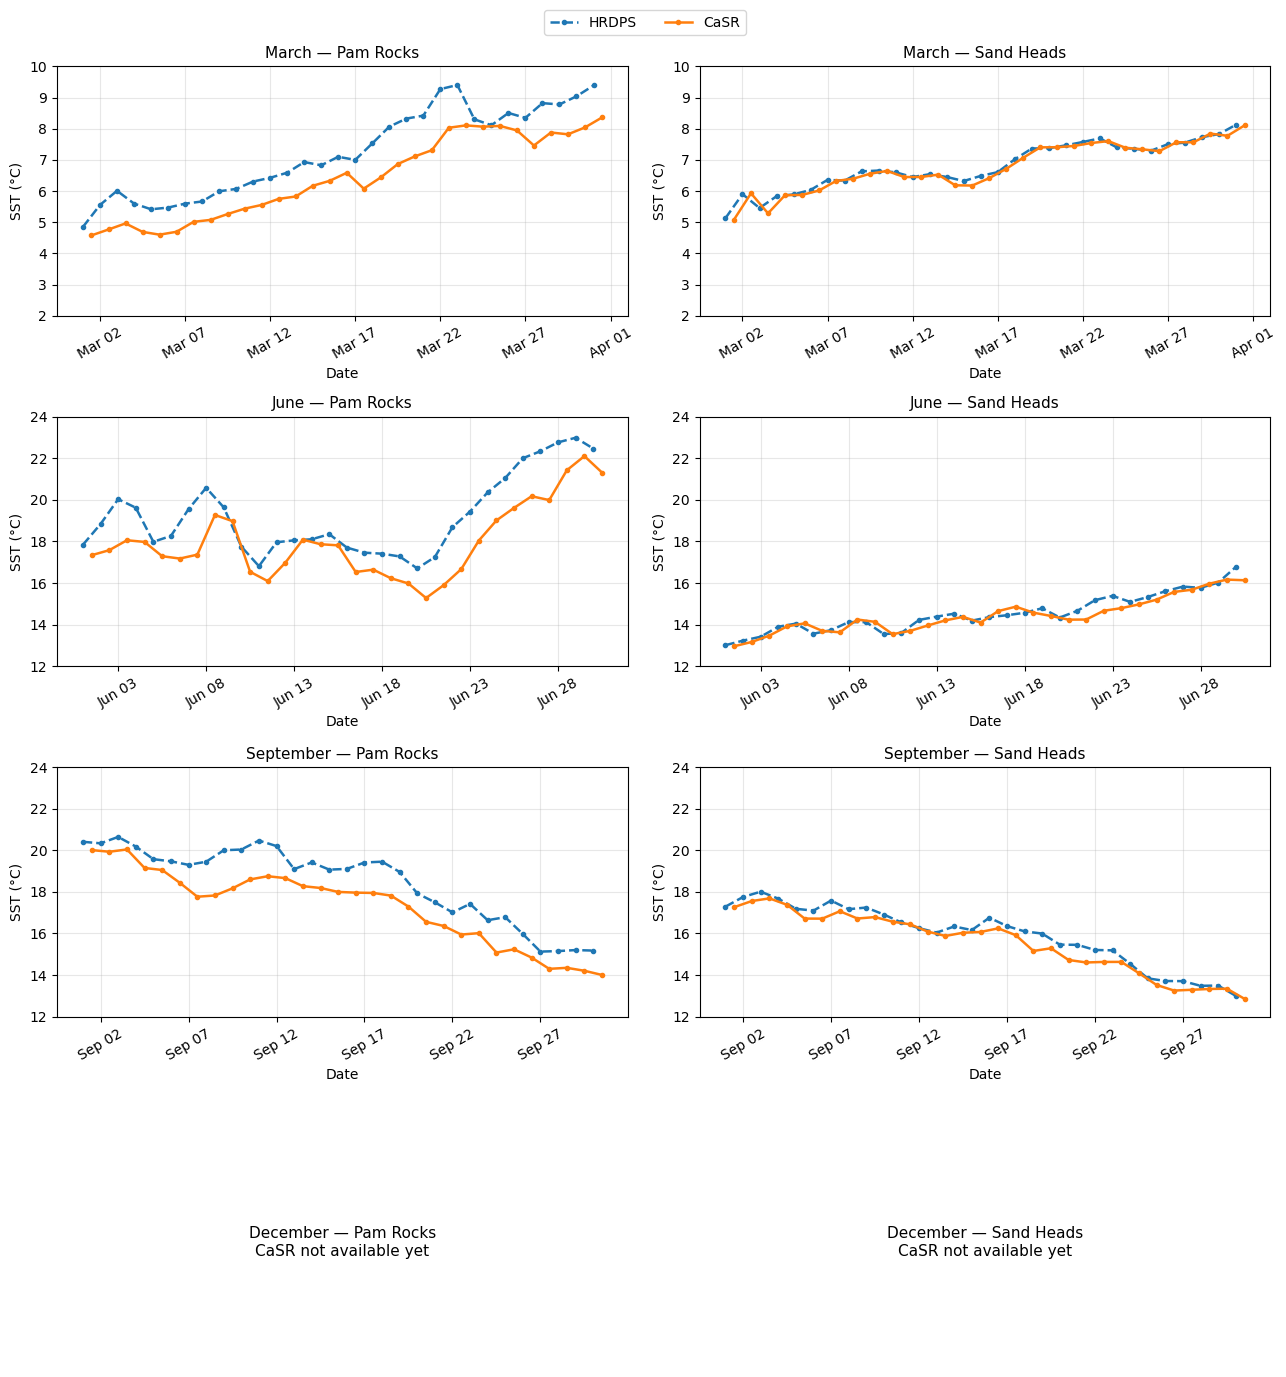

In [2]:

import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


# ============================================================
# CaSR monthly grid_T paths
# ============================================================
path_CaSR_mar_t = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_CaSR_jun_t = (
    '/ocean/jqiu/results/Flux/flux_00jun23_CaSR/'
    'SalishSea_1d_20230601_20230630_grid_T.nc'
)

path_CaSR_sep_t = (
    '/ocean/jqiu/results/Flux/flux_00sep23_CaSR/'
    'SalishSea_1d_20230901_20230930_grid_T.nc'
)

# December CaSR is not available yet
# path_CaSR_dec_t = (
#     '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
#     'SalishSea_1d_20231201_20231231_grid_T.nc'
# )


# ============================================================
# HRDPS server base path
# ============================================================
path_HRDPS_base = (
    '/results2/SalishSea/nowcast-green.202111'
)


# ============================================================
# Stations
# ============================================================
stations = [
    {
        'name': 'Pam Rocks',
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    {
        'name': 'Sand Heads',
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
]


# ============================================================
# Month information
#
# ylim is manually controlled for each month.
# Change these values yourself after looking at the plots.
# ============================================================
months = [
    {
        'name': 'March',
        'short': 'Mar',
        'month_num': 3,
        'month_str': 'mar',
        'ndays': 31,
        'casr_path': path_CaSR_mar_t,

        # manually set March SST range
        'ylim': (2, 10),
    },

    {
        'name': 'June',
        'short': 'Jun',
        'month_num': 6,
        'month_str': 'jun',
        'ndays': 30,
        'casr_path': path_CaSR_jun_t,

        # manually set June SST range
        'ylim': (12, 24),
    },

    {
        'name': 'September',
        'short': 'Sep',
        'month_num': 9,
        'month_str': 'sep',
        'ndays': 30,
        'casr_path': path_CaSR_sep_t,

        # manually set September SST range
        'ylim': (12, 24),
    },

    # ========================================================
    # December: uncomment when CaSR is ready
    # ========================================================
    # {
    #     'name': 'December',
    #     'short': 'Dec',
    #     'month_num': 12,
    #     'month_str': 'dec',
    #     'ndays': 31,
    #     'casr_path': path_CaSR_dec_t,
    #     'ylim': (5, 12),
    # },
]


# ============================================================
# Surface layer
# ============================================================
depth_idx = 0


# ============================================================
# Function to build HRDPS daily file path
#
# Example:
#
# /results2/SalishSea/nowcast-green.202111/
# 01mar23/
# SalishSea_1d_20230301_20230301_grid_T.nc
# ============================================================
def get_hrdps_path(month_num, month_str, day_num):

    date_str = (
        f'2023'
        f'{month_num:02d}'
        f'{day_num:02d}'
    )

    folder = (
        f'{day_num:02d}'
        f'{month_str}'
        f'23'
    )

    filename = (
        f'SalishSea_1d_'
        f'{date_str}_{date_str}_grid_T.nc'
    )

    return os.path.join(
        path_HRDPS_base,
        folder,
        filename
    )


# ============================================================
# Read all SST time series
#
# Structure:
#
# March
#   Pam Rocks
#   Sand Heads
#
# June
#   Pam Rocks
#   Sand Heads
#
# September
#   Pam Rocks
#   Sand Heads
# ============================================================
all_data = []


for month in months:


    # ========================================================
    # Open CaSR monthly file
    # ========================================================
    casr_ds = xr.open_dataset(
        month['casr_path']
    )

    # ========================================================
    # CaSR time
    # ========================================================
    casr_time = casr_ds[
        'time_counter'
    ].values


    # ========================================================
    # Create calendar dates for HRDPS
    #
    # These are used for plotting so that all daily HRDPS
    # files appear on a continuous monthly time axis.
    # ========================================================
    hrdps_time = pd.date_range(
        start=f"2023-{month['month_num']:02d}-01",
        periods=month['ndays'],
        freq='D'
    )


    # ========================================================
    # Prepare storage for HRDPS SST
    #
    # One list for each station
    # ========================================================
    hrdps_sst = {
        station['name']: []
        for station in stations
    }


    # ========================================================
    # Read HRDPS daily files
    # ========================================================
    for day in range(
        1,
        month['ndays'] + 1
    ):

        hrdps_path = get_hrdps_path(
            month_num=month['month_num'],
            month_str=month['month_str'],
            day_num=day
        )


        # ----------------------------------------------------
        # Safety check
        # ----------------------------------------------------
        if not os.path.exists(hrdps_path):


            # Add NaN for both stations
            for station in stations:
                hrdps_sst[
                    station['name']
                ].append(np.nan)

            continue


        # ----------------------------------------------------
        # Open daily HRDPS file
        # ----------------------------------------------------
        with xr.open_dataset(
            hrdps_path
        ) as hrdps_ds:

            for station in stations:

                value = hrdps_ds[
                    'votemper'
                ].isel(
                    time_counter=0,
                    deptht=depth_idx,
                    y=station['y'],
                    x=station['x']
                ).values

                # convert scalar array -> float
                value = float(value)

                # --------------------------------------------
                # Mask zero/bad values
                # --------------------------------------------
                if (
                    not np.isfinite(value)
                    or value == 0
                ):
                    value = np.nan


                hrdps_sst[
                    station['name']
                ].append(value)


    # ========================================================
    # Read CaSR monthly SST for each station
    # ========================================================
    month_data = []

    for station in stations:

        casr_sst = casr_ds[
            'votemper'
        ].isel(
            deptht=depth_idx,
            y=station['y'],
            x=station['x']
        ).values


        # ----------------------------------------------------
        # Convert bad / zero values to NaN
        # ----------------------------------------------------
        casr_sst = np.asarray(
            casr_sst,
            dtype=float
        )

        casr_sst[
            (~np.isfinite(casr_sst))
            | (casr_sst == 0)
        ] = np.nan


        month_data.append({
            'month': month['name'],
            'short': month['short'],
            'month_num': month['month_num'],
            'station': station['name'],
            'y': station['y'],
            'x': station['x'],

            'casr_time': casr_time,
            'casr_sst': casr_sst,

            'hrdps_time': hrdps_time,
            'hrdps_sst': np.asarray(
                hrdps_sst[station['name']],
                dtype=float
            ),

            'ylim': month['ylim'],
        })


    all_data.append(
        month_data
    )

    casr_ds.close()


# ============================================================
# Plot
#
# 4 rows × 2 columns
#
#              Pam Rocks       Sand Heads
#
# March
# June
# September
# December     blank           blank
# ============================================================
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(13, 14),

    # Different seasons have different SST ranges
    sharex=False,
    sharey=False
)


# ============================================================
# Plot available months
# ============================================================
for row, month_data in enumerate(all_data):

    for col, data in enumerate(month_data):

        ax = axes[row, col]


        # ====================================================
        # HRDPS
        # ====================================================
        ax.plot(
            data['hrdps_time'],
            data['hrdps_sst'],
            marker='o',
            markersize=3,
            linewidth=1.8,
            linestyle='--',
            label='HRDPS'
        )


        # ====================================================
        # CaSR
        # ====================================================
        ax.plot(
            data['casr_time'],
            data['casr_sst'],
            marker='o',
            markersize=3,
            linewidth=1.8,
            linestyle='-',
            label='CaSR'
        )


        # ====================================================
        # Manual temperature range
        #
        # Same month uses the same y range
        # for both stations.
        # ====================================================
        ax.set_ylim(
            data['ylim']
        )


        # ====================================================
        # Title
        # ====================================================
        ax.set_title(
            f"{data['month']} — "
            f"{data['station']}",
            fontsize=11
        )


        # ====================================================
        # Every panel gets x-axis labels/ticks
        # ====================================================
        ax.set_xlabel(
            'Date'
        )

        ax.set_ylabel(
            'SST (°C)'
        )


        # ====================================================
        # Date ticks
        #
        # Every 5 days
        # ====================================================
        ax.xaxis.set_major_locator(
            mdates.DayLocator(
                interval=5
            )
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter(
                '%b %d'
            )
        )


        # ====================================================
        # Rotate date labels slightly
        # ====================================================
        ax.tick_params(
            axis='x',
            labelrotation=30
        )


        # ====================================================
        # Grid
        # ====================================================
        ax.grid(
            True,
            alpha=0.3
        )


# ============================================================
# December row
#
# CaSR is not available yet
# ============================================================
for col, station in enumerate(stations):

    axes[3, col].axis('off')

    axes[3, col].text(
        0.5,
        0.5,
        f"December — {station['name']}\n"
        f"CaSR not available yet",
        transform=axes[3, col].transAxes,
        ha='center',
        va='center',
        fontsize=11
    )


# ============================================================
# Shared legend
#
# Only one legend needed for the entire figure
# ============================================================
handles, labels = (
    axes[0, 0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.985)
)




# ============================================================
# Layout
# ============================================================
plt.tight_layout(
    rect=[0, 0, 1, 0.965]
)

plt.show()



## What's Wrong with Air Temperature?

### Extract Forcing Data in the 4 Months

In [ ]:
# Extract forcing data at 2 locations
# for March, June, September, and December 2023

import xarray as xr
import pandas as pd
from pathlib import Path
import glob


# ============================================================
# 1. Paths
# ============================================================

casr_dir = Path("/ocean/jqiu/forcings/CaSR")

hrdps_dir = Path(
    "/results/forcing/atmospheric/continental2.5/nemo_forcing"
)


# ============================================================
# 2. Months to process
# ============================================================

year = 2023

months = [
    9,
    12,
]


# ============================================================
# 3. Only read these variables
# ============================================================

forcing_vars = [
    "solar",
    "precip",
    "therm_rad",
    "tair",
    "qair",
    "u_wind",
    "atmpres",
    "v_wind",
]


# ============================================================
# 4. Grid indices
# ============================================================

stations = {
    "PamRocks": {
        "display_name": "Pam Rocks",

        "CaSR": {
            "y": 58,
            "x": 36,
        },

        "HRDPS": {
            "y": 135,
            "x": 110,
        },
    },

    "SandHeads": {
        "display_name": "Sand Heads",

        "CaSR": {
            "y": 54,
            "x": 34,
        },

        "HRDPS": {
            "y": 119,
            "x": 108,
        },
    },
}


# ============================================================
# 5. Function for extracting one grid point
# ============================================================

def save_grid_point_csv(
    ds,
    forcing_name,
    station_name,
    y_idx,
    x_idx,
    output_file,
):

    # --------------------------------------------------------
    # Extract specified grid point
    # --------------------------------------------------------

    point = ds[forcing_vars].isel(
        y=y_idx,
        x=x_idx,
    )

    # --------------------------------------------------------
    # Grid coordinates
    # --------------------------------------------------------

    grid_lat = float(
        ds["nav_lat"].isel(
            y=y_idx,
            x=x_idx,
        ).values
    )

    grid_lon = float(
        ds["nav_lon"].isel(
            y=y_idx,
            x=x_idx,
        ).values
    )

    # Convert 0--360 longitude to -180--180
    grid_lon_180 = (
        grid_lon - 360
        if grid_lon > 180
        else grid_lon
    )

    print(
        f"\n{forcing_name} - {station_name}"
    )

    print(
        f"Grid index: y={y_idx}, x={x_idx}"
    )

    print(
        f"Grid location: "
        f"lat={grid_lat:.6f}, "
        f"lon={grid_lon_180:.6f}"
    )

    # --------------------------------------------------------
    # Convert to DataFrame
    # --------------------------------------------------------

    df = point.to_dataframe().reset_index()

    # Remove x/y if xarray puts them into dataframe
    for col in ["x", "y"]:
        if col in df.columns:
            df = df.drop(columns=col)

    # --------------------------------------------------------
    # Add grid information
    # --------------------------------------------------------

    df["grid_y"] = y_idx
    df["grid_x"] = x_idx
    df["grid_lat"] = grid_lat
    df["grid_lon"] = grid_lon
    df["grid_lon_180"] = grid_lon_180

    # --------------------------------------------------------
    # Desired column order
    # --------------------------------------------------------

    columns = [
        "time_counter",
        "grid_y",
        "grid_x",
        "grid_lat",
        "grid_lon",
        "grid_lon_180",
        "solar",
        "precip",
        "therm_rad",
        "tair",
        "qair",
        "u_wind",
        "atmpres",
        "v_wind",
    ]

    df = df[columns]

    # --------------------------------------------------------
    # Sort chronologically
    # --------------------------------------------------------

    df = df.sort_values(
        "time_counter"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Write CSV
    # --------------------------------------------------------

    df.to_csv(
        output_file,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S",
    )

    print(
        f"Saved: {output_file}"
    )

    print(
        f"Number of records: {len(df)}"
    )

    return df


# ============================================================
# 6. Process each month
# ============================================================

for month in months:

    # Month as two-digit string:
    # 3 -> "03"
    # 6 -> "06"
    # 9 -> "09"
    # 12 -> "12"
    month_str = f"{month:02d}"

    print("\n" + "=" * 70)
    print(
        f"Processing {year}-{month_str}"
    )
    print("=" * 70)

    # --------------------------------------------------------
    # Find files
    # --------------------------------------------------------

    casr_files = sorted(
        glob.glob(
            str(
                casr_dir
                / f"CaSR_y{year}m{month_str}d*.nc"
            )
        )
    )

    hrdps_files = sorted(
        glob.glob(
            str(
                hrdps_dir
                / f"hrdps_y{year}m{month_str}d*.nc"
            )
        )
    )

    print(
        f"CaSR files  : {len(casr_files)}"
    )

    print(
        f"HRDPS files : {len(hrdps_files)}"
    )

    # --------------------------------------------------------
    # Check files exist
    # --------------------------------------------------------

    if len(casr_files) == 0:
        print(
            f"WARNING: No CaSR files found "
            f"for {year}-{month_str}"
        )

    if len(hrdps_files) == 0:
        print(
            f"WARNING: No HRDPS files found "
            f"for {year}-{month_str}"
        )

    # --------------------------------------------------------
    # Open CaSR dataset
    # --------------------------------------------------------

    ds_casr = None

    if len(casr_files) > 0:

        ds_casr = xr.open_mfdataset(
            casr_files,
            combine="by_coords",
            parallel=True,
            chunks={
                "time_counter": 24,
            },
        )[forcing_vars]

    # --------------------------------------------------------
    # Open HRDPS dataset
    # --------------------------------------------------------

    ds_hrdps = None

    if len(hrdps_files) > 0:

        ds_hrdps = xr.open_mfdataset(
            hrdps_files,
            combine="by_coords",
            parallel=True,
            chunks={
                "time_counter": 24,
            },
        )[forcing_vars]

    # --------------------------------------------------------
    # Process stations
    # --------------------------------------------------------

    for station_key, station_info in stations.items():

        station_name = station_info[
            "display_name"
        ]

        # ====================================================
        # CaSR
        # ====================================================

        if ds_casr is not None:

            y_idx = station_info["CaSR"]["y"]
            x_idx = station_info["CaSR"]["x"]

            output_file = (
                f"CaSR_"
                f"{station_key}_"
                f"{year}{month_str}.csv"
            )

            save_grid_point_csv(
                ds=ds_casr,
                forcing_name="CaSR",
                station_name=station_name,
                y_idx=y_idx,
                x_idx=x_idx,
                output_file=output_file,
            )

        # ====================================================
        # HRDPS
        # ====================================================

        if ds_hrdps is not None:

            y_idx = station_info["HRDPS"]["y"]
            x_idx = station_info["HRDPS"]["x"]

            output_file = (
                f"HRDPS_"
                f"{station_key}_"
                f"{year}{month_str}.csv"
            )

            save_grid_point_csv(
                ds=ds_hrdps,
                forcing_name="HRDPS",
                station_name=station_name,
                y_idx=y_idx,
                x_idx=x_idx,
                output_file=output_file,
            )

    # --------------------------------------------------------
    # Close datasets after finishing this month
    # --------------------------------------------------------

    if ds_casr is not None:
        ds_casr.close()

    if ds_hrdps is not None:
        ds_hrdps.close()

    print(
        f"\nFinished {year}-{month_str}"
    )


# ============================================================
# 7. Finished
# ============================================================

print("\nAll months done.")

### Visualize Temperature Time Series

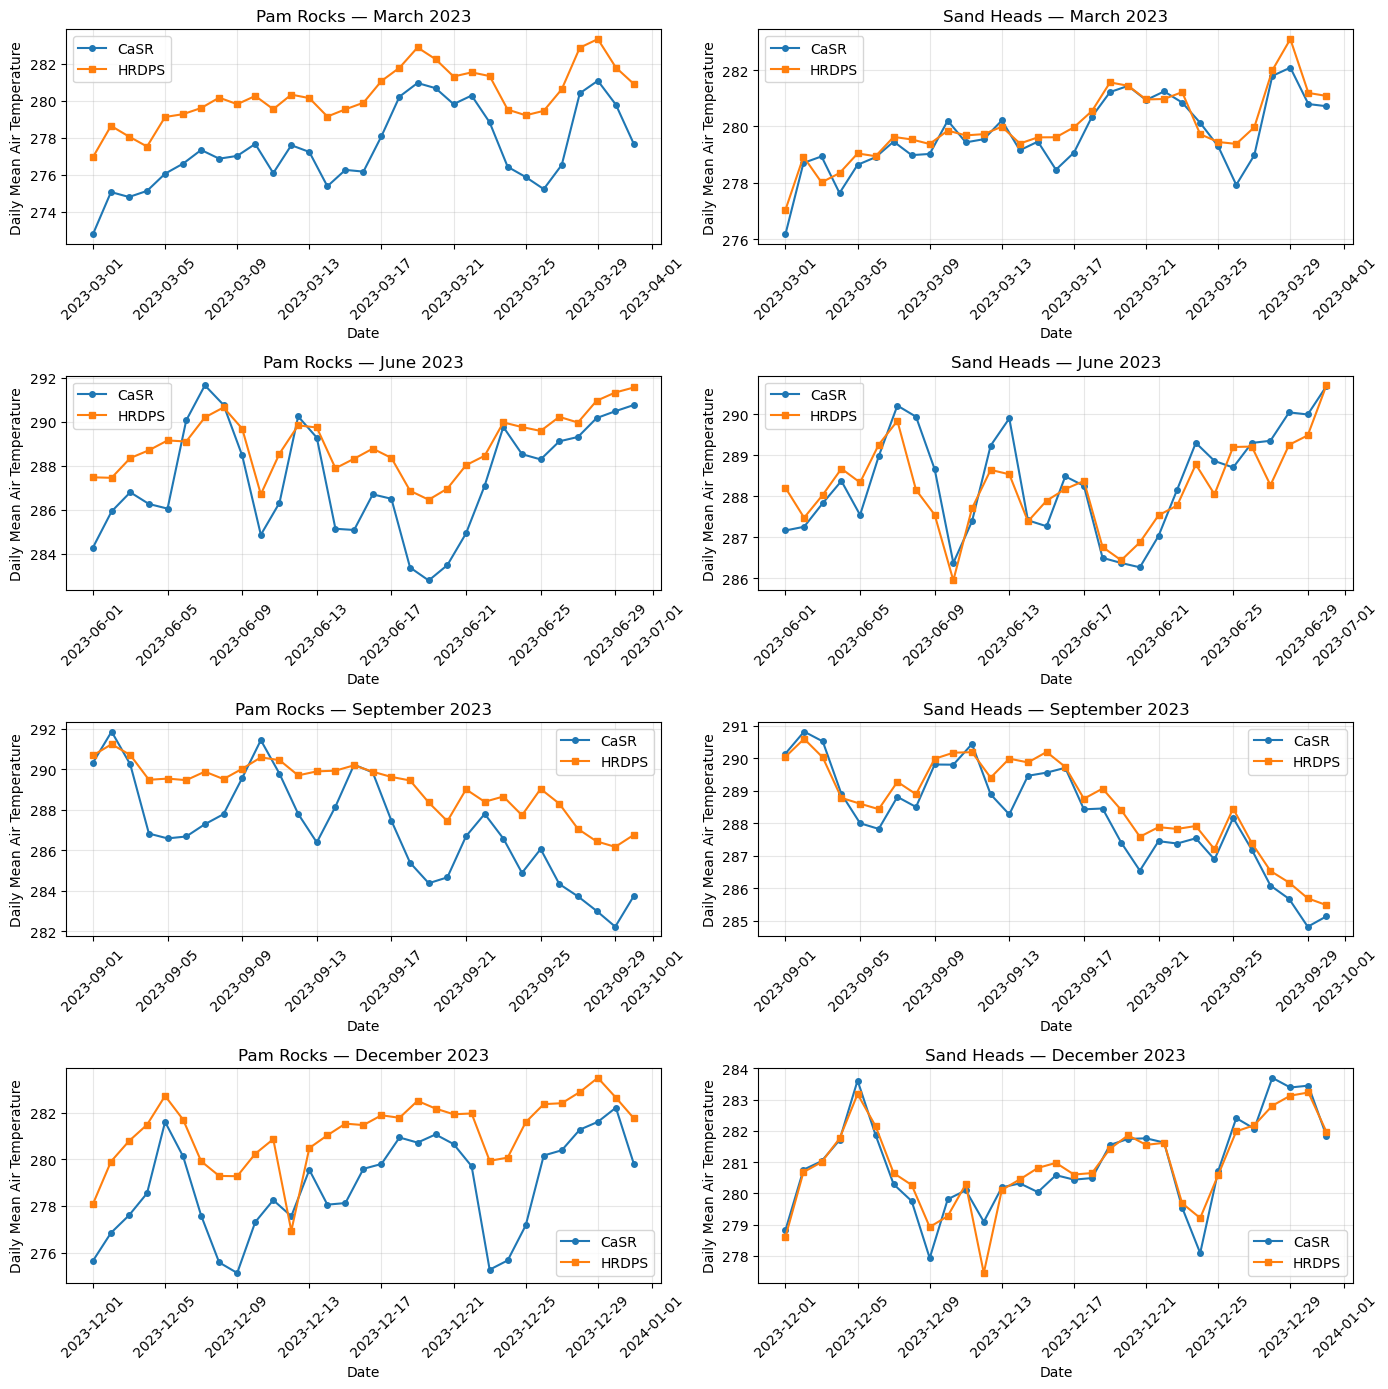

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. Base path
# ============================================================

base_dir = Path(
    "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_Forcing_Sites"
)


# ============================================================
# 2. Months to plot
# ============================================================

months = {
    "Mar": {
        "month_num": "03",
        "folder": "00Mar2023_flux",
        "title": "March 2023",
    },

    "Jun": {
        "month_num": "06",
        "folder": "00Jun2023_flux",
        "title": "June 2023",
    },

    "Sep": {
        "month_num": "09",
        "folder": "00Sep2023_flux",
        "title": "September 2023",
    },

    "Dec": {
        "month_num": "12",
        "folder": "00Dec2023_flux",
        "title": "December 2023",
    },
}


# ============================================================
# 3. Locations
# ============================================================

locations = {
    "Pam Rocks": "PamRocks",
    "Sand Heads": "SandHeads",
}


# ============================================================
# 4. Read CSV and calculate daily mean air temperature
# ============================================================

def read_daily_temperature(path):

    df = pd.read_csv(path)

    # Convert time to datetime
    df["time_counter"] = pd.to_datetime(
        df["time_counter"]
    )

    # Set time as index
    df = df.set_index("time_counter")

    # Daily mean air temperature
    daily_tair = (
        df["tair"]
        .resample("1D")
        .mean()
    )

    return daily_tair


# ============================================================
# 5. Plot
#
#    Rows    = months
#    Columns = locations
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 14),
)


# ============================================================
# 6. Loop through months and locations
# ============================================================

for row, (month_name, month_info) in enumerate(months.items()):

    month_num = month_info["month_num"]

    month_title = month_info["title"]

    for col, (location_title, station_name) in enumerate(
        locations.items()
    ):

        ax = axes[row, col]

        # ----------------------------------------------------
        # File paths
        # ----------------------------------------------------

        casr_path = (
            base_dir
            / f"CaSR_{station_name}_2023{month_num}.csv"
        )

        hrdps_path = (
            base_dir
            / f"HRDPS_{station_name}_2023{month_num}.csv"
        )


        # ----------------------------------------------------
        # Read data
        # ----------------------------------------------------

        casr = read_daily_temperature(
            casr_path
        )

        hrdps = read_daily_temperature(
            hrdps_path
        )

        # ----------------------------------------------------
        # Plot CaSR
        # ----------------------------------------------------

        ax.plot(
            casr.index,
            casr.values,
            marker="o",
            markersize=4,
            linewidth=1.5,
            label="CaSR",
        )

        # ----------------------------------------------------
        # Plot HRDPS
        # ----------------------------------------------------

        ax.plot(
            hrdps.index,
            hrdps.values,
            marker="s",
            markersize=4,
            linewidth=1.5,
            label="HRDPS",
        )

        # ----------------------------------------------------
        # Figure formatting
        # ----------------------------------------------------

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.set_title(
            f"{location_title} — {month_title}",
            fontsize=12,
        )

        ax.set_ylabel(
            "Daily Mean Air Temperature"
        )

        ax.set_xlabel(
            "Date"
        )

        ax.legend()

        ax.tick_params(
            axis="x",
            rotation=45,
        )





# ============================================================
# 8. Layout
# ============================================================

plt.tight_layout()


# ============================================================
# 9. Show
# ============================================================

plt.show()

In [ ]:
# hourly visualization in June

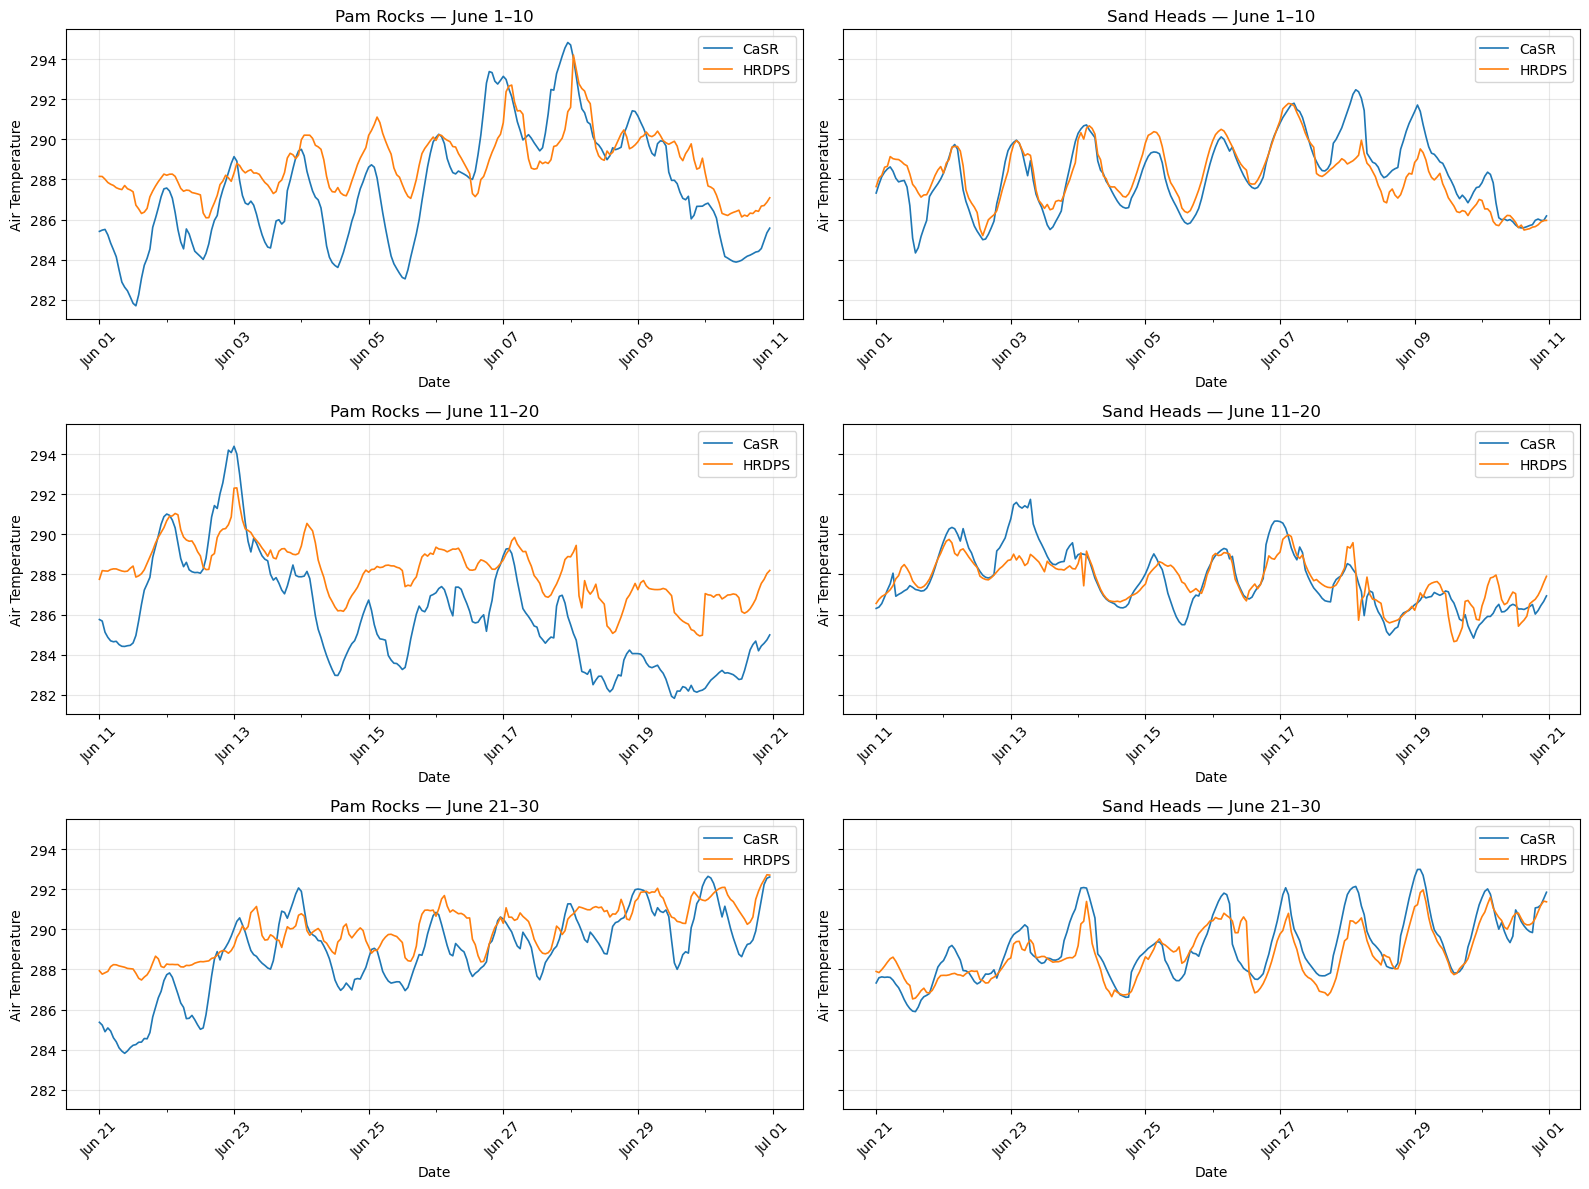

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path


# ============================================================
# 1. Base path
# ============================================================

base_dir = Path(
    "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/00MMM2023"
)


# ============================================================
# 2. June only
# ============================================================

month_num = "06"
month_title = "June 2023"


# ============================================================
# 3. Locations
# ============================================================

locations = {
    "Pam Rocks": "PamRocks",
    "Sand Heads": "SandHeads",
}


# ============================================================
# 4. Time periods
#
#    Split June into three sections so hourly variability
#    is easier to see
# ============================================================

periods = [
    (
        "June 1–10",
        pd.Timestamp("2023-06-01 00:00"),
        pd.Timestamp("2023-06-10 23:59"),
    ),
    (
        "June 11–20",
        pd.Timestamp("2023-06-11 00:00"),
        pd.Timestamp("2023-06-20 23:59"),
    ),
    (
        "June 21–30",
        pd.Timestamp("2023-06-21 00:00"),
        pd.Timestamp("2023-06-30 23:59"),
    ),
]


# ============================================================
# 5. Read CSV and calculate hourly mean air temperature
# ============================================================

def read_hourly_temperature(path):

    df = pd.read_csv(path)

    # Convert time to datetime
    df["time_counter"] = pd.to_datetime(
        df["time_counter"]
    )

    # Set time as index
    df = df.set_index("time_counter")

    # Make sure timestamps are sorted
    df = df.sort_index()

    # Hourly mean air temperature
    hourly_tair = df["tair"]

    return hourly_tair


# ============================================================
# 6. Read June data
# ============================================================

data = {}

for location_title, station_name in locations.items():

    casr_path = (
        base_dir
        / f"CaSR_{station_name}_2023{month_num}.csv"
    )

    hrdps_path = (
        base_dir
        / f"HRDPS_{station_name}_2023{month_num}.csv"
    )

    data[location_title] = {
        "CaSR": read_hourly_temperature(casr_path),
        "HRDPS": read_hourly_temperature(hrdps_path),
    }


# ============================================================
# 7. Plot
#
#    Rows    = three June periods
#    Columns = two locations
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 12),
    sharey=True,
)


# ============================================================
# 8. Loop through periods and locations
# ============================================================

for row, (period_title, start_time, end_time) in enumerate(periods):

    for col, location_title in enumerate(locations.keys()):

        ax = axes[row, col]

        # ----------------------------------------------------
        # Select current time period
        # ----------------------------------------------------

        casr = data[location_title]["CaSR"].loc[
            start_time:end_time
        ]

        hrdps = data[location_title]["HRDPS"].loc[
            start_time:end_time
        ]


        # ----------------------------------------------------
        # Plot CaSR hourly
        # ----------------------------------------------------

        ax.plot(
            casr.index,
            casr.values,
            linewidth=1.2,
            label="CaSR",
        )


        # ----------------------------------------------------
        # Plot HRDPS hourly
        # ----------------------------------------------------

        ax.plot(
            hrdps.index,
            hrdps.values,
            linewidth=1.2,
            label="HRDPS",
        )


        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.set_title(
            f"{location_title} — {period_title}",
            fontsize=12,
        )

        ax.set_ylabel(
            "Air Temperature"
        )

        ax.set_xlabel(
            "Date"
        )

        ax.legend()


        # ----------------------------------------------------
        # Date formatting
        #
        # Major tick every 2 days
        # Minor tick every day
        # ----------------------------------------------------

        ax.xaxis.set_major_locator(
            mdates.DayLocator(interval=2)
        )

        ax.xaxis.set_minor_locator(
            mdates.DayLocator(interval=1)
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%b %d")
        )

        ax.tick_params(
            axis="x",
            rotation=45,
        )



# ============================================================
# 10. Layout
# ============================================================

plt.tight_layout()


# ============================================================
# 11. Show
# ============================================================

plt.show()

### Could Be Altitude?

Recall that `temperature level` is `1.5m` in `CaSR` and `2m` in `HRDPS`. And the temperature hight is even more doubtful considering that the `CaSR` may involve land areas near Pam Rocks.

We download `CaSR_v3.2_P_GZ_SFC` (Geopotential height) to see what height we are actually using.

In [3]:
# integrate CaSR file (only one time counter)
import os
import xarray as xr

# ============================================================
# Paths
# ============================================================

data_dir = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_CaSR_Altitude"

input_files = [
    os.path.join(data_dir, "CaSR_v3.2_P_GZ_SFC_rlon141-175_rlat386-420_2020-2023.nc"),
    os.path.join(data_dir, "CaSR_v3.2_P_GZ_SFC_rlon141-175_rlat421-455_2020-2023.nc"),
    os.path.join(data_dir, "CaSR_v3.2_P_GZ_SFC_rlon141-175_rlat456-490_2020-2023.nc"),
    os.path.join(data_dir, "CaSR_v3.2_P_GZ_SFC_rlon176-210_rlat386-420_2020-2023.nc"),
    os.path.join(data_dir, "CaSR_v3.2_P_GZ_SFC_rlon176-210_rlat421-455_2020-2023.nc"),
    os.path.join(data_dir, "CaSR_v3.2_P_GZ_SFC_rlon176-210_rlat456-490_2020-2023.nc"),
]

output_file = os.path.join(
    data_dir,
    "CaSR_v3.2_P_GZ_SFC_single_time.nc"
)

# ============================================================
# Read only the first time step from each tile
# ============================================================

tiles = []

for f in input_files:

    print("Reading:", os.path.basename(f))

    with xr.open_dataset(f, engine="netcdf4") as ds:

        # Keep only the first time step
        if "time" in ds.dims:
            tile = ds.isel(time=0, drop=True).load()
        else:
            tile = ds.load()

    tiles.append(tile)

print("\nAll tiles loaded.")

# ============================================================
# Combine tiles according to coordinates
# ============================================================

combined = xr.combine_by_coords(tiles)

print("\nCombined dataset:")
print(combined)

# ============================================================
# Remove old output file if it exists
# ============================================================

if os.path.exists(output_file):
    os.remove(output_file)

# ============================================================
# Save
# ============================================================

combined.to_netcdf(
    output_file,
    mode="w",
    engine="netcdf4"
)

print("Saved to:")


# ============================================================
# Verify that the saved file can be opened
# ============================================================

with xr.open_dataset(output_file, engine="netcdf4") as ds_check:
    print("\nVerification:")
    print(ds_check)

Reading: CaSR_v3.2_P_GZ_SFC_rlon141-175_rlat386-420_2020-2023.nc
Reading: CaSR_v3.2_P_GZ_SFC_rlon141-175_rlat421-455_2020-2023.nc
Reading: CaSR_v3.2_P_GZ_SFC_rlon141-175_rlat456-490_2020-2023.nc
Reading: CaSR_v3.2_P_GZ_SFC_rlon176-210_rlat386-420_2020-2023.nc
Reading: CaSR_v3.2_P_GZ_SFC_rlon176-210_rlat421-455_2020-2023.nc
Reading: CaSR_v3.2_P_GZ_SFC_rlon176-210_rlat456-490_2020-2023.nc

All tiles loaded.

Combined dataset:
<xarray.Dataset> Size: 119kB
Dimensions:             (rlon: 70, rlat: 105)
Coordinates:
    lon                 (rlat, rlon) float32 29kB 235.9 236.0 ... 238.0 238.2
    lat                 (rlat, rlon) float32 29kB 43.38 43.42 ... 54.46 54.5
  * rlon                (rlon) float64 560B -22.8 -22.71 ... -16.68 -16.59
  * rlat                (rlat) float64 840B -9.45 -9.36 -9.27 ... -0.18 -0.09
Data variables:
    rotated_pole        (rlon, rlat) int32 29kB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    CaSR_v3.2_P_GZ_SFC  (rlat, rlon) float32 29kB 14.22 24.87 ... 102.1 111.5
At

/tmp/ipykernel_3943343/2330445035.py:51: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined = xr.combine_by_coords(tiles)
/tmp/ipykernel_3943343/2330445035.py:51: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined = xr.combine_by_coords(tiles)
/tmp/ipykernel_3943343/2330445035.py:51: FutureWarning: In a

In [4]:
import xarray as xr

path_CaSR_GZ='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_CaSR_Altitude/CaSR_v3.2_P_GZ_SFC.nc'
ds_CaSR_GZ=xr.open_dataset(path_CaSR_GZ)
print(ds_CaSR_GZ)


<xarray.Dataset> Size: 119kB
Dimensions:             (rlon: 70, rlat: 105)
Coordinates:
    lon                 (rlat, rlon) float32 29kB ...
    lat                 (rlat, rlon) float32 29kB ...
  * rlon                (rlon) float64 560B -22.8 -22.71 ... -16.68 -16.59
  * rlat                (rlat) float64 840B -9.45 -9.36 -9.27 ... -0.18 -0.09
Data variables:
    rotated_pole        (rlon, rlat) int32 29kB ...
    CaSR_v3.2_P_GZ_SFC  (rlat, rlon) float32 29kB ...
Attributes:
    Conventions:  CF-1.6
    source:       https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/
    institution:  Environment and Climate Change Canada / Environnement et Ch...
    title:        Canadian Surface Reanalysis (CaSR) / Réanalyse Canadienne d...
    contact:      rcas-casr@ec.gc.ca
    licence:      These data are produced and provided by the Environment and...


In [1]:
# Actual Height (10 m)

import xarray as xr
import numpy as np

path_CaSR_GZ = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_CaSR_Altitude/CaSR_v3.2_P_GZ_SFC.nc'

ds_CaSR_GZ = xr.open_dataset(path_CaSR_GZ)

# 2D latitude / longitude
lat = ds_CaSR_GZ['lat'].values
lon = ds_CaSR_GZ['lon'].values

# altitude / geopotential-height variable
gz = ds_CaSR_GZ['CaSR_v3.2_P_GZ_SFC'].values

locations = {
    'Howe Sound - Pam Rocks': (49.49, 360-123.3),
    'Sand Heads Lightstation': (49.11, 360-123.3),
}

for name, (target_lat, target_lon) in locations.items():

    # 对这个小区域，直接用经纬度差寻找最近格点即可
    # longitude方向乘 cos(lat)，避免经纬度尺度不同
    dist2 = (
        (lat - target_lat)**2
        + ((lon - target_lon) * np.cos(np.deg2rad(target_lat)))**2
    )

    # 找到二维数组中最小值的位置
    iy, ix = np.unravel_index(np.nanargmin(dist2), dist2.shape)

    print(f'\n{name}')
    print(f'  station lat/lon : {target_lat:.4f}, {target_lon:.4f}')
    print(f'  nearest grid    : rlat index={iy}, rlon index={ix}')
    print(f'  grid lat/lon    : {lat[iy, ix]:.4f}, {lon[iy, ix]:.4f}')
    print(f'  GZ_SFC value    : {gz[iy, ix]}')


Howe Sound - Pam Rocks
  station lat/lon : 49.4900, 236.7000
  nearest grid    : rlat index=58, rlon index=36
  grid lat/lon    : 49.4832, 236.6761
  GZ_SFC value    : 37.89683151245117

Sand Heads Lightstation
  station lat/lon : 49.1100, 236.7000
  nearest grid    : rlat index=54, rlon index=34
  grid lat/lon    : 49.0810, 236.6707
  GZ_SFC value    : 0.0


**Unit: 10m**

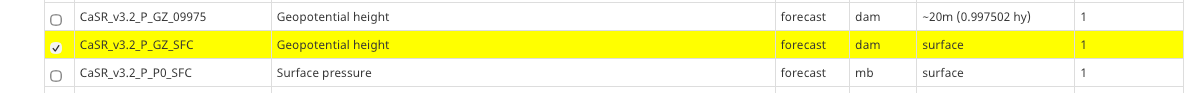

Apparently, Pam Rock and other places in fjords are impacted by `Altitude` (decreasing temperature) and `Land/Sea Averaging`(making more extreme).

